### 0. Importing

In [4]:
#%pip install xgboost
#%pip install lightgbm
import time 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,classification_report
df = pd.read_csv('PartI_dev.csv')
X = df.drop('Y', axis=1)
Y = df['Y']
print(df.Y.value_counts()) # We have 11 classes 
print(df.shape)
# =====================================================================
# DATA CLEANING/EXPLORATION
#
# =====================================================================
# Descriptive stats
print(df.describe())
print(df.info()) #All float values. No need for encoding.
print(df.isnull().sum()) # All defined values. No missing data.



# =====================================================================
# ANOVA F-TEST (appropriate for continuous features vs categorical target)
# =====================================================================
anova_results = []

for col in X.columns:
    groups = [X[col][Y == cls] for cls in Y.unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({'Feature': col, 'F-Statistic': f_stat, 'P-Value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('F-Statistic', ascending=False)
anova_df['Significant'] = anova_df['P-Value'] < 0.05

print("=== ANOVA Results ===")
print(anova_df.to_string(index=False))

# =====================================================================
# CHI-SQUARED TEST (only valid for non-negative integer/categorical features)
# Binning floats into quartiles to make it applicable
# =====================================================================
chi2_results = []

for col in X.columns:
    binned = pd.qcut(X[col], q=4, labels=False, duplicates='drop')
    contingency_table = pd.crosstab(binned, Y)
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2-Statistic': chi2_stat, 'P-Value': p_val, 'DOF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2-Statistic', ascending=False)
chi2_df['Significant'] = chi2_df['P-Value'] < 0.05

print("\n=== Chi-Squared Results (binned into quartiles) ===")
print(chi2_df.to_string(index=False))

# =====================================================================
# SUMMARY — features significant in both tests
# =====================================================================
both_significant = set(anova_df[anova_df['Significant']]['Feature']) & \
                   set(chi2_df[chi2_df['Significant']]['Feature'])

print(f"\nFeatures significant in both tests ({len(both_significant)}):")
print(both_significant)


Y
1     4255
2     4255
3     4255
4     4255
5     4255
6     4255
7     4255
8     4255
9     4255
10    4255
11    4255
Name: count, dtype: int64
(46805, 49)
                 X1            X2            X3            X4            X5  \
count  46805.000000  46805.000000  46805.000000  4.680500e+04  46805.000000   
mean      -0.000003      0.000002      0.000002 -1.196022e-06      0.000001   
std        0.000075      0.000057      0.000256  6.524010e-05      0.000061   
min       -0.013756     -0.003989     -0.013538 -1.277087e-02     -0.008345   
25%       -0.000023     -0.000024     -0.000112 -1.877998e-05     -0.000024   
50%       -0.000003      0.000002      0.000002 -8.788122e-07      0.000001   
75%        0.000017      0.000027      0.000116  1.681469e-05      0.000027   
max        0.005807      0.004485      0.005403  1.461591e-03      0.000840   

                 X6            X7            X8            X9           X10  \
count  4.680500e+04  46805.000000  46805.000000 

<Axes: >

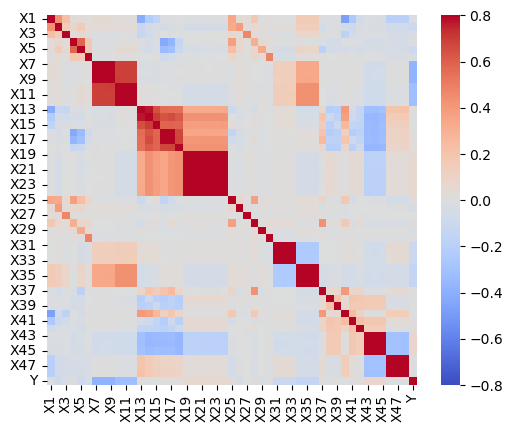

In [5]:
# =====================================================================
# Correlation matrix
#
# =====================================================================
sns.heatmap(df.corr(), square=True, vmax=.8, vmin=-.8, center=0, cmap='coolwarm')

# Correlation matrix shows elements of multicollinearity.
# When deciding the model we gotta be careful about multicollinearity as this will affect the model's performance
# additional considerations may be needed in terms of scaling and dimensionality reduction.


### Part 0 Data Prep

In [6]:
scalar = StandardScaler()
encoder = LabelEncoder()
pca = PCA()

data = df.copy()
Y = data['Y']
Y = encoder.fit_transform(Y) # apply just to prevent any mix ups with the model. We can decode the predictions later on.
X = data.drop(columns=['Y']).astype('float32') # Prevent excessive computation and memory usage
# 70/30 split for dev/test
x_dev, x_test, y_dev, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

X_dev_scaled = scalar.fit_transform(x_dev)
X_test_scaled = scalar.transform(x_test)

print(f"X_dev shape: {x_dev.shape}, X_test shape: {x_test.shape}")
Y_dev = pd.DataFrame(y_dev, columns=['Y'])
Y_test = pd.DataFrame(y_test, columns=['Y'])
print(f"Y_dev shape: {Y_dev.value_counts()}, Y_test shape: {Y_test.value_counts()}")

X_dev shape: (32763, 48), X_test shape: (14042, 48)
Y_dev shape: Y 
5     2979
0     2979
10    2979
2     2979
9     2979
8     2978
6     2978
4     2978
3     2978
7     2978
1     2978
Name: count, dtype: int64, Y_test shape: Y 
1     1277
7     1277
8     1277
6     1277
4     1277
3     1277
9     1276
0     1276
2     1276
5     1276
10    1276
Name: count, dtype: int64


### PART 1

## For traditional I will be using ensemble methods

Due to the high concentration of features and classes the best model to choose would be RandomForest as a baseline then move in XGBoost
- Why? The overall goal is generalization and efficiency since the models we will be implementating and testing on will see a unseen data set and also will have to generalize to 11 class and 48 features. Ensemble methods are robust to noise in that they average predictions from multiple learners. Additionally we want to prevent extensive hyperparameter tuning and have an easy way to deal with the level of multicolinearity from this data set so the procedure will be as follows

* Step 1: RandomForest hyper parameter tuning on X_Dev set -> Save results & params
* Step 2: XGBoost hyper parameter tuning on X_Dev Set -> Save results & params
* Step 3: Analysis 
* Step 4: Run best model on train and test set report results and possible reasons for issues.




###  Part 1 Model Hyperparameter selection


In [ ]:
#========================================
# Model CV
#========================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9,None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10]
}
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'alpha': [0.01, 0.001, 0.0001]
}

grid_rf = GridSearchCV(RandomForestClassifier(n_jobs=-1,random_state=42, verbose=1), param_grid_rf, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1) #Using a CPU with n_jobs=-1
grid_xgb = GridSearchCV(XGBClassifier(n_jobs=-1, random_state=42), param_grid_xgb, cv=kfold, scoring='f1_macro', n_jobs=-1) #Using a Cuda - GPU with tree_method="gpu_hist"

In [6]:
grid_rf.fit(X_dev_scaled, y_dev)
best_params_rf = grid_rf.best_params_
best_score_rf = grid_rf.best_score_
    
print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best score for Random Forest:", grid_rf.best_score_)



Fitting 10 folds for each of 90 candidates, totalling 900 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    1.3s


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}
Best score for Random Forest: 0.7411551232694142


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    2.5s finished


In [7]:
grid_xgb.fit(X_dev_scaled, y_dev)

print("Best parameters for XGBoost:", grid_xgb.best_params_)
print("Best score for XGBoost:", grid_xgb.best_score_)


Best parameters for XGBoost: {'alpha': 0.0001, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best score for XGBoost: 0.7490454219177575


In [7]:
#best_params_rf = grid_rf.best_params_
#best_score_rf = grid_rf.best_score_

#best_params_xgb = grid_xgb.best_params_
#best_score_xgb = grid_xgb.best_score_
best_params_rf = {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300} # From Grid so we dont have to rerun
best_params_xgb ={'alpha': 0.0001, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300} # From Grid so we dont have to rerun

### Part 1.2 Model Training and Analysis

In [8]:
rf = RandomForestClassifier(n_jobs=-1, random_state=42, **best_params_rf)
xg = XGBClassifier(n_jobs=-1, **best_params_xgb, random_state=42)  

In [9]:
print("Random Forest Training:")
start = time.time()
rf.fit(x_dev, y_dev)
print("Random Forest Training Time:", time.time() - start)

print("XGBoost Training:")
start = time.time()
xg.fit(x_dev, y_dev)
print("XGBoost Training Time:", time.time() - start)


Random Forest Training:
Random Forest Training Time: 16.35206913948059
XGBoost Training:
XGBoost Training Time: 28.93604350090027


In [10]:
y_pred_rf = rf.predict(x_test)
y_pred_xg = xg.predict(x_test)

              precision    recall  f1-score   support

           0       0.65      0.75      0.70      1276
           1       0.70      0.75      0.72      1277
           2       0.70      0.75      0.73      1276
           3       0.76      0.79      0.78      1277
           4       0.61      0.50      0.55      1277
           5       0.63      0.49      0.55      1276
           6       0.96      0.98      0.97      1277
           7       0.68      0.70      0.69      1277
           8       0.70      0.73      0.72      1277
           9       0.73      0.71      0.72      1276
          10       1.00      1.00      1.00      1276

    accuracy                           0.74     14042
   macro avg       0.74      0.74      0.74     14042
weighted avg       0.74      0.74      0.74     14042



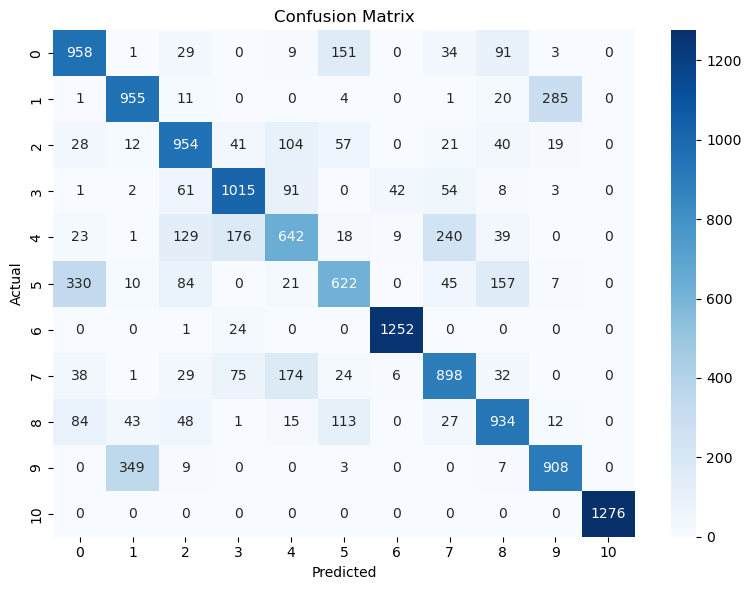

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Confusion Matrix ──────────────────────────────────────────────
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.70      0.71      0.70      1276
           1       0.71      0.75      0.73      1277
           2       0.71      0.74      0.72      1276
           3       0.79      0.76      0.78      1277
           4       0.58      0.56      0.57      1277
           5       0.59      0.58      0.59      1276
           6       0.97      0.97      0.97      1277
           7       0.70      0.71      0.71      1277
           8       0.71      0.71      0.71      1277
           9       0.75      0.72      0.73      1276
          10       1.00      1.00      1.00      1276

    accuracy                           0.75     14042
   macro avg       0.75      0.75      0.75     14042
weighted avg       0.75      0.75      0.75     14042



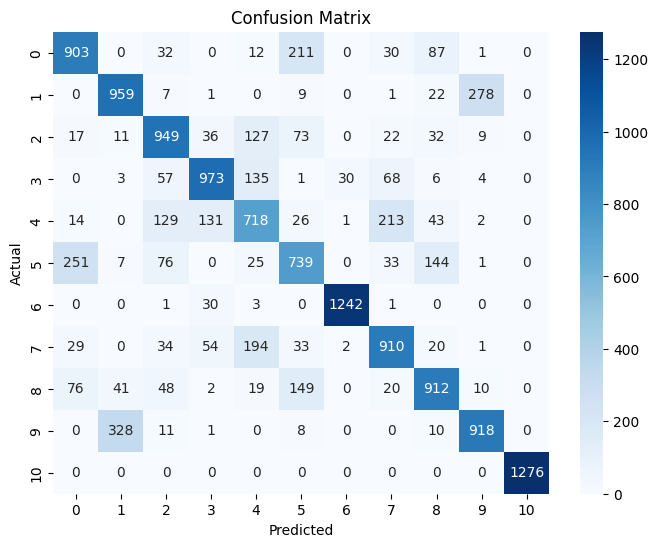

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print(classification_report(y_test, y_pred_xg))
cm = confusion_matrix(y_test, y_pred_xg)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

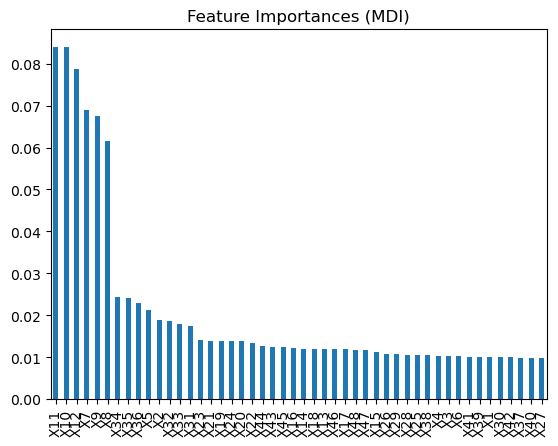

In [14]:
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
forest_importances.plot.bar()
plt.title("Feature Importances (MDI)")
plt.show()

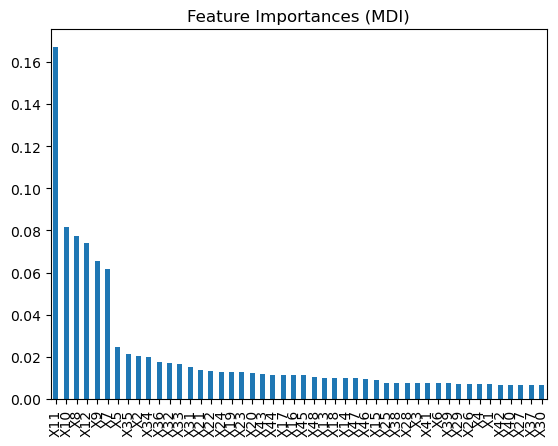

In [15]:
importances = xg.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
forest_importances.plot.bar()
plt.title("Feature Importances (MDI)")
plt.show()

### Saving Model



Training Time: 48.13546657562256
Random Forest Training Performance:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      4255
           2       1.00      1.00      1.00      4255
           3       1.00      1.00      1.00      4255
           4       1.00      1.00      1.00      4255
           5       1.00      1.00      1.00      4255
           6       1.00      1.00      1.00      4255
           7       1.00      1.00      1.00      4255
           8       1.00      1.00      1.00      4255
           9       1.00      1.00      1.00      4255
          10       1.00      1.00      1.00      4255
          11       1.00      1.00      1.00      4255

    accuracy                           1.00     46805
   macro avg       1.00      1.00      1.00     46805
weighted avg       1.00      1.00      1.00     46805

Model saved to rf_part1_model.joblib


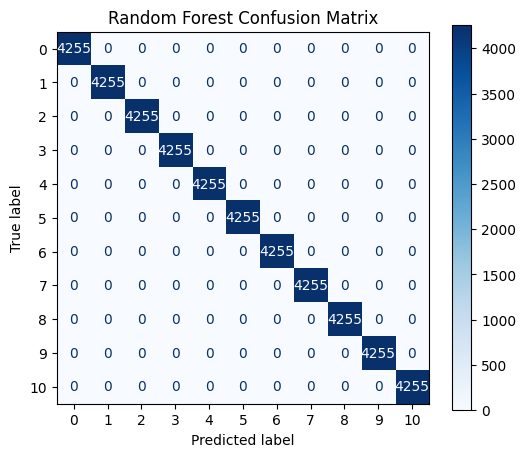

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import time 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

#{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 300}

# Set to True for training, False for test/inference
TRAINING = True  # Change to False for test

dev_csv = 'PartI_dev.csv'  # Development set
test_csv = 'NEW_TEST_FILE.csv'  # Replace with actual test file when needed
model_path = 'rf_part1_model.joblib'
# Only use X1-X125 and Y
def load_data(csv_path):
    data = pd.read_csv(csv_path)
    X = data.drop(columns=['Y'])
    y = data['Y']
    return X, y

# Define pipeline and parameters
rf_params = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'log2'
}
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(class_weight='balanced', **rf_params))
])


if TRAINING:
    X_dev, y_dev = load_data(dev_csv)
    time_start = time.time()
    model = pipe.fit(X_dev, y_dev)
    print("Training Time:", time.time() - time_start)
    y_pred = model.predict(X_dev)
    print('Random Forest Training Performance:')
    print(classification_report(y_dev, y_pred))
    joblib.dump({'model': model, 'params': rf_params}, model_path)
    print(f'Model saved to {model_path}')
    cm = confusion_matrix(y_dev, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    plt.title('Random Forest Confusion Matrix')
    plt.show()
else:
    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model file {model_path} not found! Train first.')
    saved = joblib.load(model_path)
    model = saved['model']
    # Use dev set for demonstration; replace with test_csv for real test
    X_test, y_test = load_data(test_csv)
    time_start = time.time()
    y_pred = model.predict(X_test)
    print("Prediction Time:", time.time() - time_start)
    print('Random Forest Test Performance:')
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    plt.title('Random Forest Confusion Matrix')
    plt.show()
